<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/OSA_April2026_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("OSA_2023.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df = df.drop(columns=[
    "height_(in)", "weight_(lb)",
    "bmi>30", "neck>17",
    "mf_>2", "ban+"
], errors="ignore")

df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns=["osa", "osa_severity", "ahi"], errors="ignore")
y = df["osa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [51]:
X.head()

,age,sex,height_(m),weight_(kg),bmi,neck,airway_mf,ban
0,49,0.0,1.68,39.0,20,12,1,0
1,42,0.0,1.68,50.0,27,13,1,0
2,58,1.0,1.73,42.0,21,14,1,0
3,44,0.0,1.52,36.0,23,15,1,0
4,55,0.0,1.63,41.0,23,15,1,0


In [14]:
# ================================
# MODELS (KNN replaced with ANN)
# ================================
models = {
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=2000))]),
        {"clf__C": [0.01, 0.1, 1, 10],
         "clf__class_weight": [None, "balanced"]}
    ),

    "SVM": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SVC(probability=True))]),
        {"clf__C": [0.1, 1, 10],
         "clf__kernel": ["rbf", "linear"],
         "clf__gamma": ["scale", "auto"],
         "clf__class_weight": [None, "balanced"]}
    ),

    "Random Forest": (
        Pipeline([("clf", RandomForestClassifier(random_state=42))]),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth": [3, 5, 10],
         "clf__min_samples_leaf": [1, 5],
         "clf__class_weight": [None, "balanced"]}
    ),

    "Gradient Boosting": (
        Pipeline([("clf", GradientBoostingClassifier())]),
        {"clf__n_estimators": [100, 200],
         "clf__learning_rate": [0.01, 0.1],
         "clf__max_depth": [3, 5]}
    ),

    "Feedforward ANN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                max_iter=3000,
                early_stopping=True,
                validation_fraction=0.2,
                n_iter_no_change=10,
                random_state=42
            ))
        ]),
        {
            "clf__hidden_layer_sizes": [(8,), (16,), (32,)],
            "clf__activation": ["relu", "tanh"],
            "clf__alpha": [0.0001, 0.001, 0.01],
            "clf__learning_rate_init": [0.001, 0.01]
        }
    )
}

# ================================
# **TRAIN + TUNE**
# ================================

In [15]:
best_models = {}
results = []

for name, (pipe, grid) in models.items():
    print(f"Tuning {name}...")

    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)

    best_models[name] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:,1]

    results.append([
        name,
        gs.best_score_,
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(results, columns=["Model","CV F1","Test F1","ROC-AUC"])
print("\nMODEL COMPARISON:\n", results_df)

# ================================
# METRICS TABLE
# ================================
metrics = []

for name, model in best_models.items():
    metrics.append([
        name,
        accuracy_score(y_train, model.predict(X_train)),
        precision_score(y_train, model.predict(X_train)),
        recall_score(y_train, model.predict(X_train)),
        f1_score(y_train, model.predict(X_train)),

        accuracy_score(y_test, model.predict(X_test)),
        precision_score(y_test, model.predict(X_test)),
        recall_score(y_test, model.predict(X_test)),
        f1_score(y_test, model.predict(X_test)),
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Model",
    "Train Acc","Train Prec","Train Rec","Train F1",
    "Test Acc","Test Prec","Test Rec","Test F1"
])

# print("\nTRAIN vs TEST METRICS:\n", metrics_df)

Tuning Logistic Regression...
Tuning SVM...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning Feedforward ANN...

MODEL COMPARISON:
                  Model     CV F1   Test F1   ROC-AUC
0  Logistic Regression  0.722508  0.747967  0.753230
1                  SVM  0.725160  0.749004  0.738582
2        Random Forest  0.715844  0.776860  0.749771
3    Gradient Boosting  0.726214  0.758621  0.740108
4      Feedforward ANN  0.723256  0.745902  0.734310


In [16]:
selected_features

['neck', 'ban', 'bmi', 'weight_(kg)', 'sex', 'airway_mf', 'age', 'height_(m)']

In [17]:
metrics_df

,Model,Train Acc,Train Prec,Train Rec,Train F1,Test Acc,Test Prec,Test Rec,Test F1
0,Logistic Regression,0.66125,0.673704,0.776549,0.721480,0.690,0.691729,0.814159,0.747967
1,SVM,0.66500,0.667883,0.809735,0.732000,0.685,0.681159,0.831858,0.749004
2,Random Forest,0.76875,0.773006,0.836283,0.803401,0.730,0.728682,0.831858,0.776860
3,Gradient Boosting,0.70500,0.684932,0.884956,0.772201,0.685,0.668919,0.876106,0.758621
4,Feedforward ANN,0.67625,0.686654,0.785398,0.732714,0.690,0.694656,0.805310,0.745902


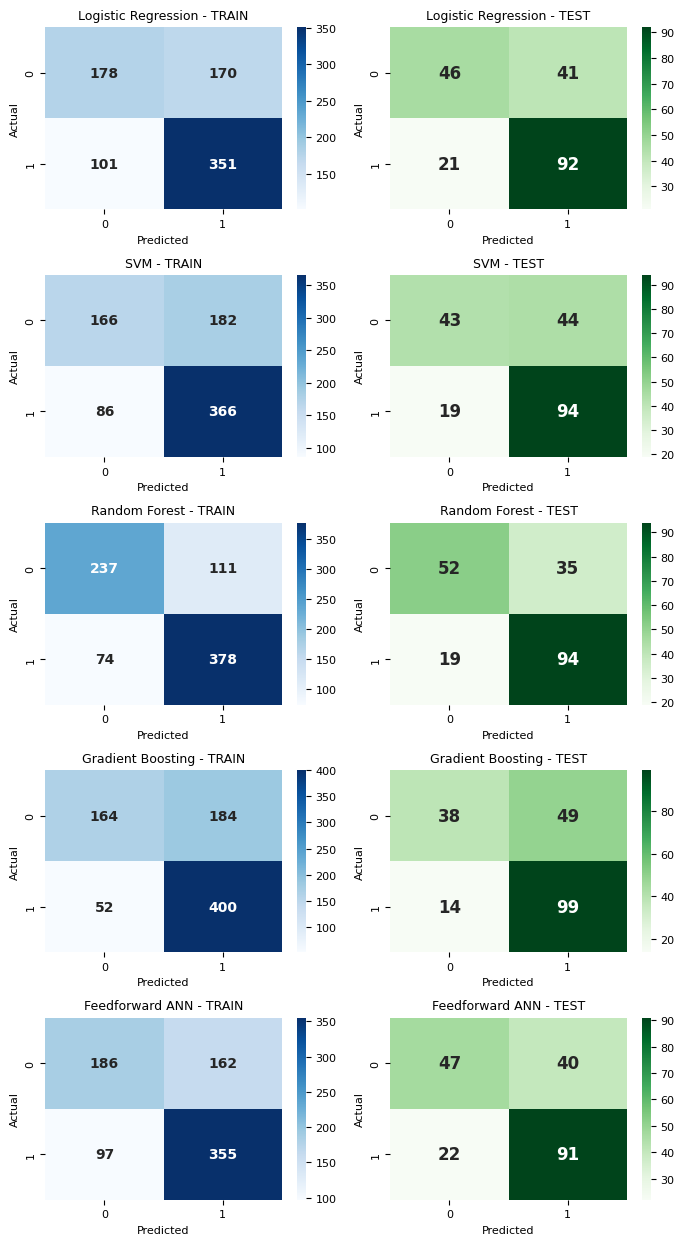

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Global font control (cleaner plots)
plt.rcParams.update({'font.size': 8})

models_items = list(best_models.items())
n_models = len(models_items)

# 👉 Rows = models, Columns = Train | Test
fig, axes = plt.subplots(n_models, 2, figsize=(7, 2.5 * n_models))

if n_models == 1:
    axes = np.array([axes])

for i, (name, model) in enumerate(models_items):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    # =========================
    # TRAIN CONFUSION MATRIX
    # =========================
    sns.heatmap(
        cm_train,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i, 0],
        annot_kws={"size": 10, "weight": "bold"}
    )
    axes[i, 0].set_title(f"{name} - TRAIN", fontsize=9)
    axes[i, 0].set_xlabel("Predicted", fontsize=8)
    axes[i, 0].set_ylabel("Actual", fontsize=8)

    # =========================
    # TEST CONFUSION MATRIX
    # =========================
    sns.heatmap(
        cm_test,
        annot=True,
        fmt="d",
        cmap="Greens",
        ax=axes[i, 1],
        annot_kws={"size": 12, "weight": "bold"}
    )
    axes[i, 1].set_title(f"{name} - TEST", fontsize=9)
    axes[i, 1].set_xlabel("Predicted", fontsize=8)
    axes[i, 1].set_ylabel("Actual", fontsize=8)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "Confusion_Matrix_All_Models_Train_Test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

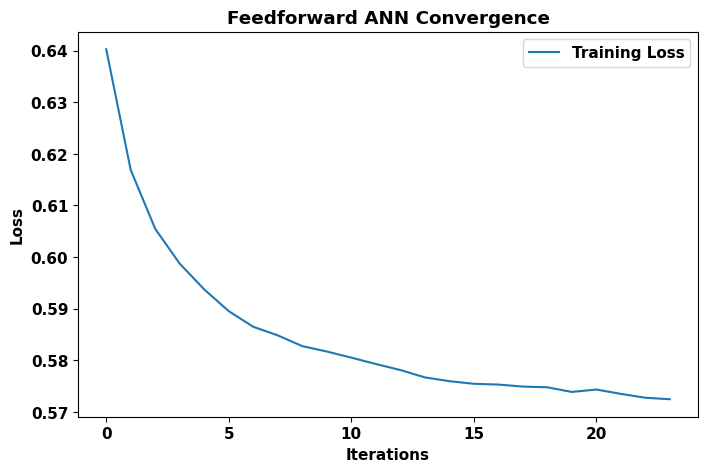

In [40]:
# ================================
# ANN CONVERGENCE CURVE
# ================================
ann = best_models["Feedforward ANN"].named_steps["clf"]

plt.figure(figsize=(8,5))
plt.plot(ann.loss_curve_, label="Training Loss")
plt.title("Feedforward ANN Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

plt.savefig("ANN_convergence.png", dpi=300)
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_results = []

for name, model in best_models.items():

    # Train predictions
    y_train_pred = model.predict(X_train)

    # Test predictions
    y_test_pred = model.predict(X_test)

    # ---- Train Metrics ----
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # ---- Test Metrics ----
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    metrics_results.append([
        name,
        train_acc, train_prec, train_rec, train_f1,
        test_acc, test_prec, test_rec, test_f1
    ])

# Create DataFrame
metrics_df = pd.DataFrame(metrics_results, columns=[
    "Model",
    "Train Accuracy", "Train Precision", "Train Recall", "Train F1",
    "Test Accuracy", "Test Precision", "Test Recall", "Test F1"
])

# Sort by best Test F1
metrics_df = metrics_df.sort_values(by="Test F1", ascending=False)

print("\n=== Final Train vs Test Performance ===")
metrics_df


=== Final Train vs Test Performance ===


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
2,Random Forest,0.76875,0.773006,0.836283,0.803401,0.730,0.728682,0.831858,0.776860
3,Gradient Boosting,0.70500,0.684932,0.884956,0.772201,0.685,0.668919,0.876106,0.758621
1,SVM,0.66500,0.667883,0.809735,0.732000,0.685,0.681159,0.831858,0.749004
0,Logistic Regression,0.66125,0.673704,0.776549,0.721480,0.690,0.691729,0.814159,0.747967
4,Feedforward ANN,0.67625,0.686654,0.785398,0.732714,0.690,0.694656,0.805310,0.745902


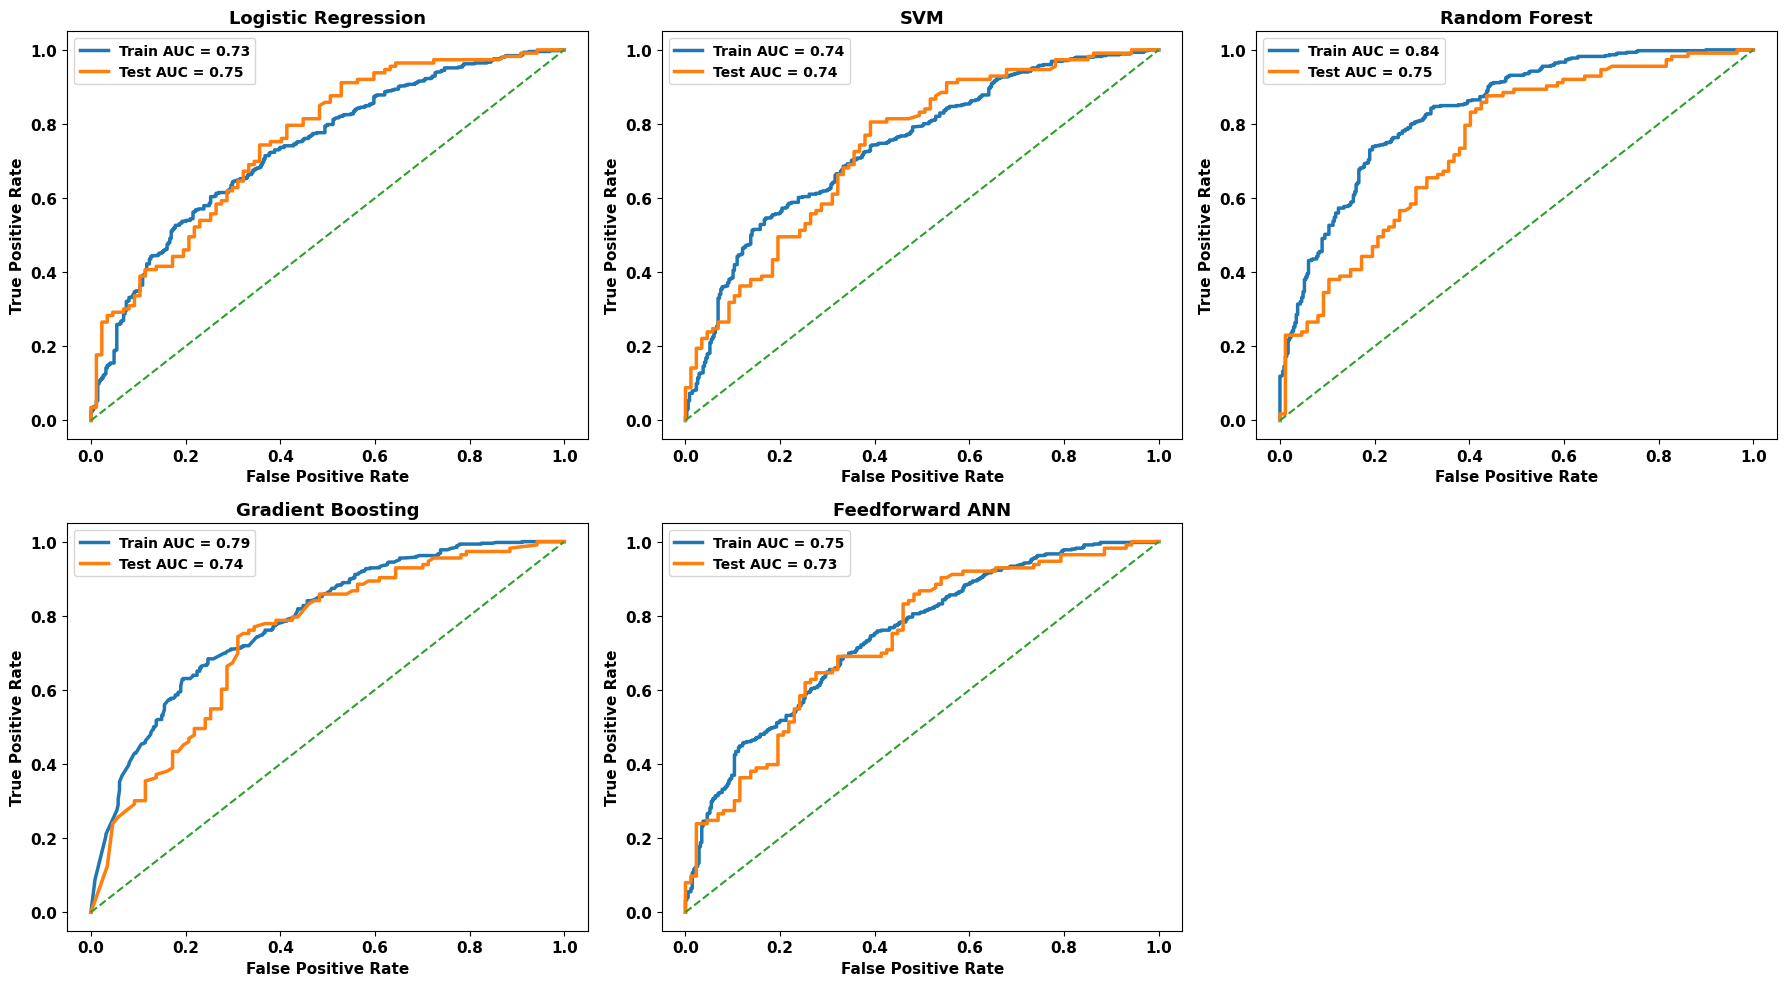

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# =========================
# GLOBAL FONT SETTINGS
# =========================
plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold"
})

models_items = list(best_models.items())
n_models = len(models_items)

n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, (name, model) in enumerate(models_items):

    ax = axes[i]

    # Probabilities
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    auc_train = roc_auc_score(y_train, y_train_prob)
    auc_test = roc_auc_score(y_test, y_test_prob)

    # =========================
    # PLOTS
    # =========================
    ax.plot(fpr_train, tpr_train, linewidth=2.5,
            label=f"Train AUC = {auc_train:.2f}")

    ax.plot(fpr_test, tpr_test, linewidth=2.5,
            label=f"Test AUC = {auc_test:.2f}")

    ax.plot([0, 1], [0, 1], '--', linewidth=1.5)

    # =========================
    # TEXT FORMATTING
    # =========================
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=11, fontweight="bold")
    ax.set_ylabel("True Positive Rate", fontsize=11, fontweight="bold")

    # Legend bold text
    legend = ax.legend(prop={'size': 10, 'weight': 'bold'})

# Turn off empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

# Save high-quality figure
plt.savefig("ROC_Curves_Matrix_BOLD.png", dpi=300, bbox_inches="tight")

plt.show()

Best Parameters: {'clf__class_weight': None, 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}

Clinical Random Forest Performance (Tuned)
Accuracy : 0.63
Precision: 0.7532467532467533
Recall   : 0.5132743362831859
F1-score : 0.6105263157894737


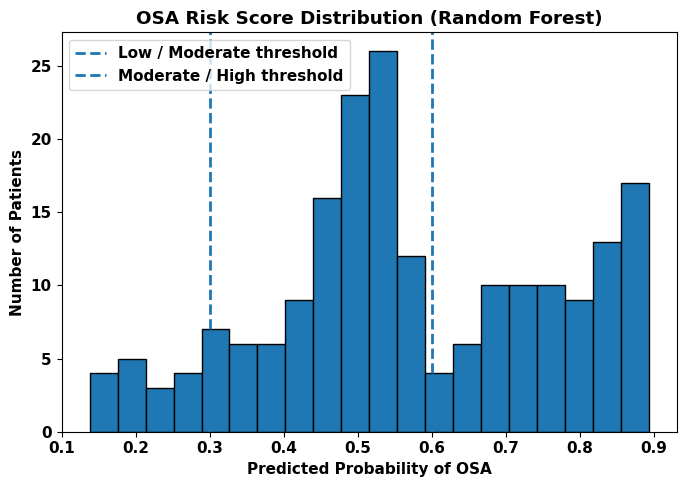

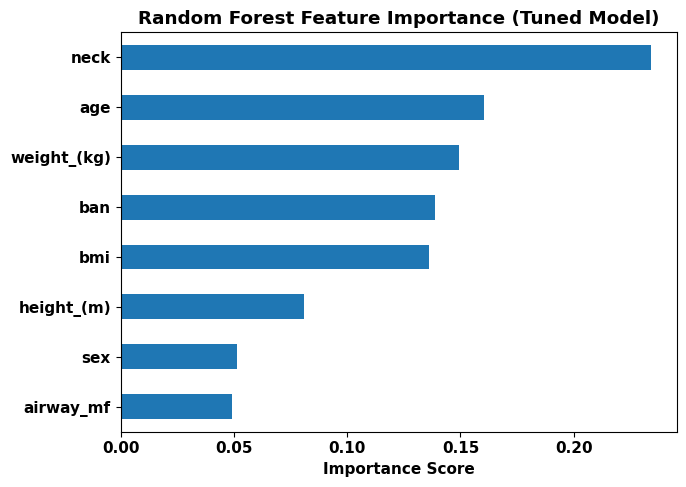

In [46]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================================
# REPRODUCIBILITY
# ================================
np.random.seed(42)

# ================================
# CROSS-VALIDATION
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================================
# RANDOM FOREST PIPELINE
# ================================
rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 5, 10],
    "clf__min_samples_leaf": [1, 5],
    "clf__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ================================
# PREDICTIONS
# ================================
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ================================
# CLINICAL RISK SYSTEM
# ================================
def risk_category(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"

def clinical_decision(p):
    return 1 if p >= 0.60 else 0

risk_df = pd.DataFrame({
    "True Label": y_test.values,
    "Probability": y_prob
})

risk_df["Risk Category"] = risk_df["Probability"].apply(risk_category)

y_pred = np.array([clinical_decision(p) for p in y_prob])

# ================================
# EVALUATION
# ================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nClinical Random Forest Performance (Tuned)")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)

# ================================
# RISK DISTRIBUTION PLOT
# ================================
plt.figure(figsize=(7,5))
plt.hist(y_prob, bins=20, edgecolor='black')

plt.axvline(0.30, linestyle='--', linewidth=2, label="Low / Moderate threshold")
plt.axvline(0.60, linestyle='--', linewidth=2, label="Moderate / High threshold")

plt.title("OSA Risk Score Distribution (Random Forest)")
plt.xlabel("Predicted Probability of OSA")
plt.ylabel("Number of Patients")
plt.legend()

plt.tight_layout()
plt.savefig("RF_Risk_Distribution.png", dpi=300)
plt.show()

# ================================
# FEATURE IMPORTANCE PLOT
# ================================
importances = best_rf.named_steps["clf"].feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(7,5))
feat_imp.plot(kind="barh")

plt.title("Random Forest Feature Importance (Tuned Model)")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.savefig("RF_Feature_Importance.png", dpi=300)
plt.show()

# ================================
# OPTIONAL: SAVE CLINICAL OUTPUT
# ================================
risk_df.to_csv("RF_Clinical_Risk_Output.csv", index=False)

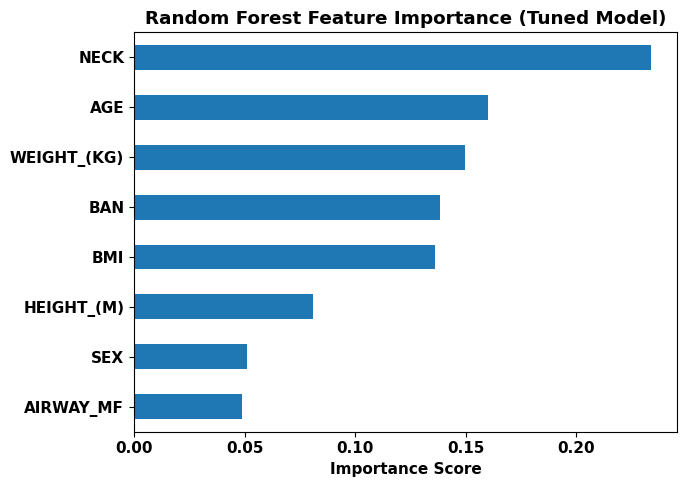

In [52]:
# ================================
# FEATURE IMPORTANCE PLOT
# ================================
importances = best_rf.named_steps["clf"].feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns.str.upper())
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(7,5))
feat_imp.plot(kind="barh")

plt.title("Random Forest Feature Importance (Tuned Model)")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.savefig("RF_Feature_Importance.png", dpi=300)
plt.show()

In [47]:
df.head()

,age,sex,height_(m),weight_(kg),bmi,neck,airway_mf,ban,ahi,osa,osa_severity
0,49,0.0,1.68,39.0,20,12,1,0,0,0,0
1,42,0.0,1.68,50.0,27,13,1,0,0,0,0
2,58,1.0,1.73,42.0,21,14,1,0,0,0,0
3,44,0.0,1.52,36.0,23,15,1,0,0,0,0
4,55,0.0,1.63,41.0,23,15,1,0,0,0,0
